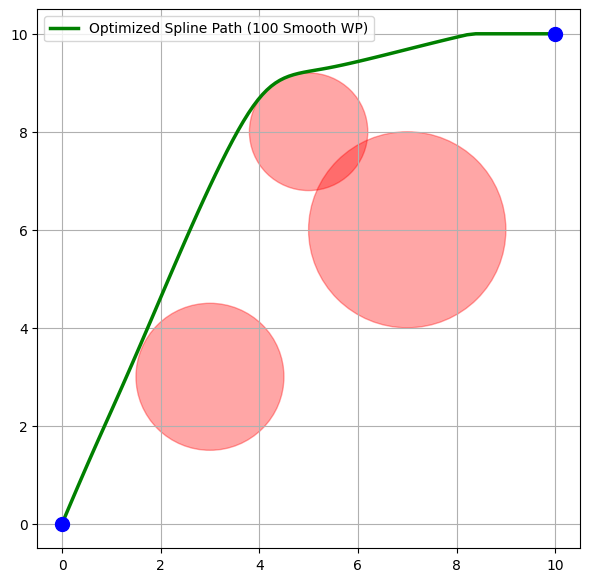

Optimized Cost: 15.8333


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

START, TARGET = np.array([0.0, 0.0]), np.array([10.0, 10.0])
NUM_CONTROL_POINTS = 5   # The "Sweet Spot" for PSO to optimize easily
NUM_WAYPOINTS = 100       # High-resolution smooth path generated via Spline

obstacles = [
    {"center": np.array([3.0, 3.0]), "radius": 1.5, "damage": 100.0},
    {"center": np.array([7.0, 6.0]), "radius": 2.0, "damage": 150.0},
    {"center": np.array([5.0, 8.0]), "radius": 1.2, "damage": 80.0}
]

def particle_swarm_optimization(f, N, T, w, c1, c2, lower_bound, upper_bound):
    dimensions = len(lower_bound)
    positions = np.random.uniform(lower_bound, upper_bound, size=(N, dimensions))
    velocities = np.random.uniform(-1.0, 1.0, size=(N, dimensions))

    personal_best_positions = np.copy(positions)
    personal_best_scores = np.array([f(p) for p in positions])

    global_best_index = np.argmin(personal_best_scores)
    global_best_position = np.copy(personal_best_positions[global_best_index])
    global_best_score = personal_best_scores[global_best_index]

    for _ in range(T):
        r1, r2 = np.random.rand(N, dimensions), np.random.rand(N, dimensions)
        velocities = (w * velocities +
                      c1 * r1 * (personal_best_positions - positions) +
                      c2 * r2 * (global_best_position - positions))
        positions = np.clip(positions + velocities, lower_bound, upper_bound)

        for i in range(N):
            score = f(positions[i])
            if score < personal_best_scores[i]:
                personal_best_scores[i] = score
                personal_best_positions[i] = np.copy(positions[i])
                if score < global_best_score:
                    global_best_score = score
                    global_best_position = np.copy(positions[i])

    return global_best_position, global_best_score

def get_smooth_path(control_points_flat):
    # Reshape to control points
    ctrl_pts = control_points_flat.reshape((NUM_CONTROL_POINTS, 2))

    # Sort control points by progression along diagonal to avoid loops
    proj = ctrl_pts[:, 0] + ctrl_pts[:, 1]
    sorted_ctrl = ctrl_pts[np.argsort(proj)]

    all_ctrl = np.vstack([START, sorted_ctrl, TARGET])

    # Use Cubic Spline to generate a beautifully smooth path
    t_ctrl = np.linspace(0, 1, len(all_ctrl))
    t_fine = np.linspace(0, 1, NUM_WAYPOINTS)

    cs_x = CubicSpline(t_ctrl, all_ctrl[:, 0])
    cs_y = CubicSpline(t_ctrl, all_ctrl[:, 1])

    smooth_path = np.column_stack((cs_x(t_fine), cs_y(t_fine)))
    return np.clip(smooth_path, 0.0, 10.0)

def path_fitness(control_points_flat):
    full_path = get_smooth_path(control_points_flat)

    # Calculate path segments length
    diffs = np.diff(full_path, axis=0)
    lengths = np.linalg.norm(diffs, axis=1)
    path_length = np.sum(lengths)

    # Calculate hazard/damage costs along the smooth path
    damage = 0.0
    for obs in obstacles:
        dists = np.linalg.norm(full_path - obs["center"], axis=1)
        inside = dists < obs["radius"]
        if np.any(inside):
            damage += np.sum((obs["radius"] - dists[inside]) * obs["damage"])

    return path_length + damage

# Optimize 5 control points (10 dimensions total)
best_control_flat, best_cost = particle_swarm_optimization(
    f=path_fitness, N=50, T=100, w=0.5, c1=1.5, c2=1.5,
    lower_bound=np.zeros(NUM_CONTROL_POINTS * 2), upper_bound=np.ones(NUM_CONTROL_POINTS * 2) * 10.0
)

optimized_path = get_smooth_path(best_control_flat)

fig, ax = plt.subplots(figsize=(7, 7))
for obs in obstacles:
    ax.add_patch(plt.Circle(obs["center"], obs["radius"], color='red', alpha=0.35))

ax.plot(optimized_path[:, 0], optimized_path[:, 1], 'g-', linewidth=2.5, label=f"Optimized Spline Path ({NUM_WAYPOINTS} Smooth WP)")
ax.scatter([START[0], TARGET[0]], [START[1], TARGET[1]], color='blue', s=100, zorder=5)
ax.set_xlim(-0.5, 10.5); ax.set_ylim(-0.5, 10.5)
ax.grid(True); ax.legend()
plt.show()
print(f"Optimized Cost: {best_cost:.4f}")